In [1]:
from datetime import timedelta
import ggcmpy
from ggcmpy.timeseries import read_ggcm_solarwind_directory, store_to_pyspedas
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np
import pandas as pd
import pathlib
import pyspedas
from pyspedas import (
    data_exists,
    get_data,
    options,
    store_data,
    tplot,
    tplot_names,
)
import xarray as xr

In [2]:
trange = ["1997-01-10/00:00:00", "1997-01-10/14:00:00"]

# Download OMNI data.
pyspedas.omni.data(trange=trange, datatype="1min", time_clip=True)

16-Mar-26 23:13:39: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/omni/omni_cdaweb/hro_1min/1997/
16-Mar-26 23:13:41: Retrying (Retry(total=2, connect=None, read=None, redirect=None, status=None)) after connection broken by 'RemoteDisconnected('Remote end closed connection without response')': /pub/data/omni/omni_cdaweb/hro_1min/1997/omni_hro_1min_19970101_v01.cdf
16-Mar-26 23:13:41: File is current: omni_data/hro_1min/1997/omni_hro_1min_19970101_v01.cdf


['IMF',
 'PLS',
 'IMF_PTS',
 'PLS_PTS',
 'percent_interp',
 'Timeshift',
 'RMS_Timeshift',
 'RMS_phase',
 'Time_btwn_obs',
 'F',
 'BX_GSE',
 'BY_GSE',
 'BZ_GSE',
 'BY_GSM',
 'BZ_GSM',
 'RMS_SD_B',
 'RMS_SD_fld_vec',
 'flow_speed',
 'Vx',
 'Vy',
 'Vz',
 'proton_density',
 'T',
 'Pressure',
 'E',
 'Beta',
 'Mach_num',
 'Mgs_mach_num',
 'x',
 'y',
 'z',
 'BSN_x',
 'BSN_y',
 'BSN_z',
 'AE_INDEX',
 'AL_INDEX',
 'AU_INDEX',
 'SYM_D',
 'SYM_H',
 'ASY_D',
 'ASY_H',
 'PC_N_INDEX']

In [3]:
# Set the plotting style.
plt.style.use("seaborn-v0_8-whitegrid")

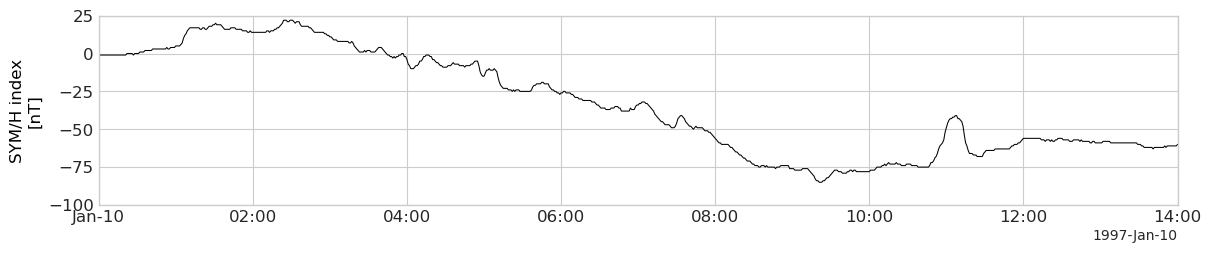

In [4]:
# Plot the SYM-H index.
vars_to_plot = ["SYM_H"]

options(vars_to_plot, "yrange", [-100, 25])
options(vars_to_plot, "alpha", 1.0)
options(vars_to_plot, "line_width", 0.75)

# Plot the geomagnetic data.
tplot(vars_to_plot, trange, ysize=2.5 * len(vars_to_plot))

In [5]:
# Extract data.
time_sym_h, data_sym_h = get_data("SYM_H")

# Create a DataFrame.
df = pd.DataFrame({"Time": time_sym_h, "SYM-H": data_sym_h})

# Set the time index to datetime for easier slicing.
df["Time"] = pd.to_datetime(df["Time"], unit="s")
df.set_index("Time", inplace=True)

In [6]:
# Classify geomagnetic storms into four categories.
def classify_storm(sym_h_min):
    if sym_h_min <= -250:
        return "Super"
    elif sym_h_min <= -100:
        return "Large"
    elif sym_h_min <= -50:
        return "Moderate"
    elif sym_h_min <= -30:
        return "Small"
    else:
        return "Quiet"


storms = []
threshold = -30
window_hours = 48  # Group events within 48 hours as one storm.

active_periods = df[df["SYM-H"] <= threshold]

if not active_periods.empty:
    # Group active times into discrete events.
    gaps = active_periods.index.to_series().diff() > timedelta(
        hours=window_hours
    )
    event_ids = gaps.cumsum()

    for _, group in active_periods.groupby(event_ids):
        # Define the event window.
        start = group.index.min()
        end = group.index.max()

        # Grab a slightly larger slice to ensure we see the full picture.
        storm_slice = df[
            start - timedelta(hours=12) : end + timedelta(hours=12)
        ]

        # Calculate the minimum.
        sym_h_min_val = storm_slice["SYM-H"].min()
        sym_h_min_time = storm_slice["SYM-H"].idxmin()

        storms.append(
            {
                "Classification": classify_storm(sym_h_min_val),
                "SYM-H Minimum (nT)": sym_h_min_val,
                "Time at SYM-H Minimum": sym_h_min_time,
            }
        )

In [7]:
# Display the result in a table.
results = pd.DataFrame(storms)
print(f"The number of storms identified: {len(results)}")
display(results)

The number of storms identified: 1


,Classification,SYM-H Minimum (nT),Time at SYM-H Minimum
0,Moderate,-85,1997-01-10 09:21:00


In [8]:
# Check each storm for Sudden Storm Commencements.
for i, row in results.iterrows():
    peak_time = row["Time at SYM-H Minimum"]
    classification = row["Classification"]

    # Define search window: 48 hours before the peak
    start_search = peak_time - timedelta(hours=48)
    end_search = peak_time

    window_df = df[start_search:end_search].copy()
    window_df["Delta_SYM-H"] = window_df["SYM-H"].diff()

    # Check for SSC Condition: An increase of >= 20 nT SYM-H in one hour
    ssc_candidates = window_df[window_df["Delta_SYM-H"] >= 20]

    print(f"\nStorm {i}: {classification}")
    print(f"  - Peak time: {peak_time}")
    print(f"  - Peak SYM-H: {row['SYM-H Minimum (nT)']} nT")

    if not ssc_candidates.empty:
        print(f"  - Potential SSC(s) found:")
        for t, jump in zip(
            ssc_candidates.index, ssc_candidates["Delta_SYM-H"]
        ):
            print(f"    * {t}: +{jump:.1f} nT jump")
    else:
        print("  - No SSC (> 20 nT jump within an hour) detected.")


Storm 0: Moderate
  - Peak time: 1997-01-10 09:21:00
  - Peak SYM-H: -85 nT
  - No SSC (> 20 nT jump within an hour) detected.


In [9]:
# Add OpenGGCM data.
RUN_NAME = "c031"
RUN_DIR = pathlib.Path("/mnt/home/germaschewski/cu1010/runs/raeder") / RUN_NAME
SW_DIR = pathlib.Path(
    "/mnt/home/germaschewski/cu1010/runs/251118_1330_c034_AZ/inp"
)
DATA_DIR = RUN_DIR

In [10]:
# OpenGGCM input data
wi = read_ggcm_solarwind_directory(SW_DIR, glob="wi.*")
store_to_pyspedas(wi)

In [11]:
# OpenGGCM ionosphere output
iono_files = sorted(DATA_DIR.glob(f"{RUN_NAME}.iof.*00"))
iof = xr.open_mfdataset(iono_files)

16-Mar-26 23:13:47: /tmp/ipykernel_3325507/1026567936.py:3: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  iof = xr.open_mfdataset(iono_files)



In [12]:
# Calculate ground magnetic perturbations and put into a DataArray.
delbp = []
delbt = []

for i in range(len(iof.time)):
    iopar_obj = ggcmpy.iono.iopar(iof.isel(time=i))
    delbp.append(iopar_obj.delbp)
    delbt.append(iopar_obj.delbt)

iof["delbp"] = xr.concat(delbp, dim="time")
iof["delbp"].attrs["long_name"] = "ground magnetic perturbation phi component"
iof["delbp"].attrs["units"] = "nT"

iof["delbt"] = xr.concat(delbt, dim="time")
iof["delbt"].attrs[
    "long_name"
] = "ground magnetic perturbation theta component"
iof["delbt"].attrs["units"] = "nT"

In [13]:
# Calculate the AL index.
ggcm_al = iof.ggcm.al_index()
ggcmpy.timeseries.store_to_pyspedas(ggcm_al["ggcm.al"])
store_data("al", data=["AL_INDEX", "ggcm.al"])

True

In [14]:
# Calculate the cross-polar-cap-potential.
cpcp = iof.ggcm.cpcp() * 1e-3
cpcp.attrs["units"] = "kV"
store_to_pyspedas(cpcp)

In [15]:
# Calculate Joule heating.
xjh = [ggcmpy.iono.iopar(iof.isel(time=i)).xjh for i in range(len(iof.time))]
iof["xjh"] = xr.concat(xjh, dim="time")
jh = iof.ggcm.jh() * 1e-9
jh.attrs["units"] = "GW"
store_to_pyspedas(jh)

In [16]:
# Calculate OpenGGCM |dB/dt|.
delbh_t_sim = iof.ggcm.delbhdelt()

In [17]:
# Calculate |dB/dt| at magnetometer stations.
delbh_t_sim_station = iof.ggcm.delbhdelt_station()

In [18]:
# Extract data and coordinates from the `delbh_t_sim_station` DataArray.
times = delbh_t_sim_station.time
stations = delbh_t_sim_station.station

var_names = []

# Store each station data.
for station in stations.values:
    var_name = f"delbh_t_sim_{station}"
    station_data = delbh_t_sim_station.sel(station=station).values
    store_data(var_name, data={"x": times, "y": station_data})
    var_names.append(var_name)

store_data("delbh_t_sim_all", data=var_names)

True

In [19]:
# Find the simulation |dB/dt| maximum and the magnetometer station where it occurs.
station_max_sim_name = (
    delbh_t_sim_station.where(
        delbh_t_sim_station == delbh_t_sim_station.max(), drop=True
    )
    .coords["station"]
    .item()
)
print(
    "The simulation data maximum at a station is",
    delbh_t_sim_station.max().item(),
    "nT/s occurring at",
    station_max_sim_name,
    ".",
)

The simulation data maximum at a station is 1.246759057044983 nT/s occurring at DIK .


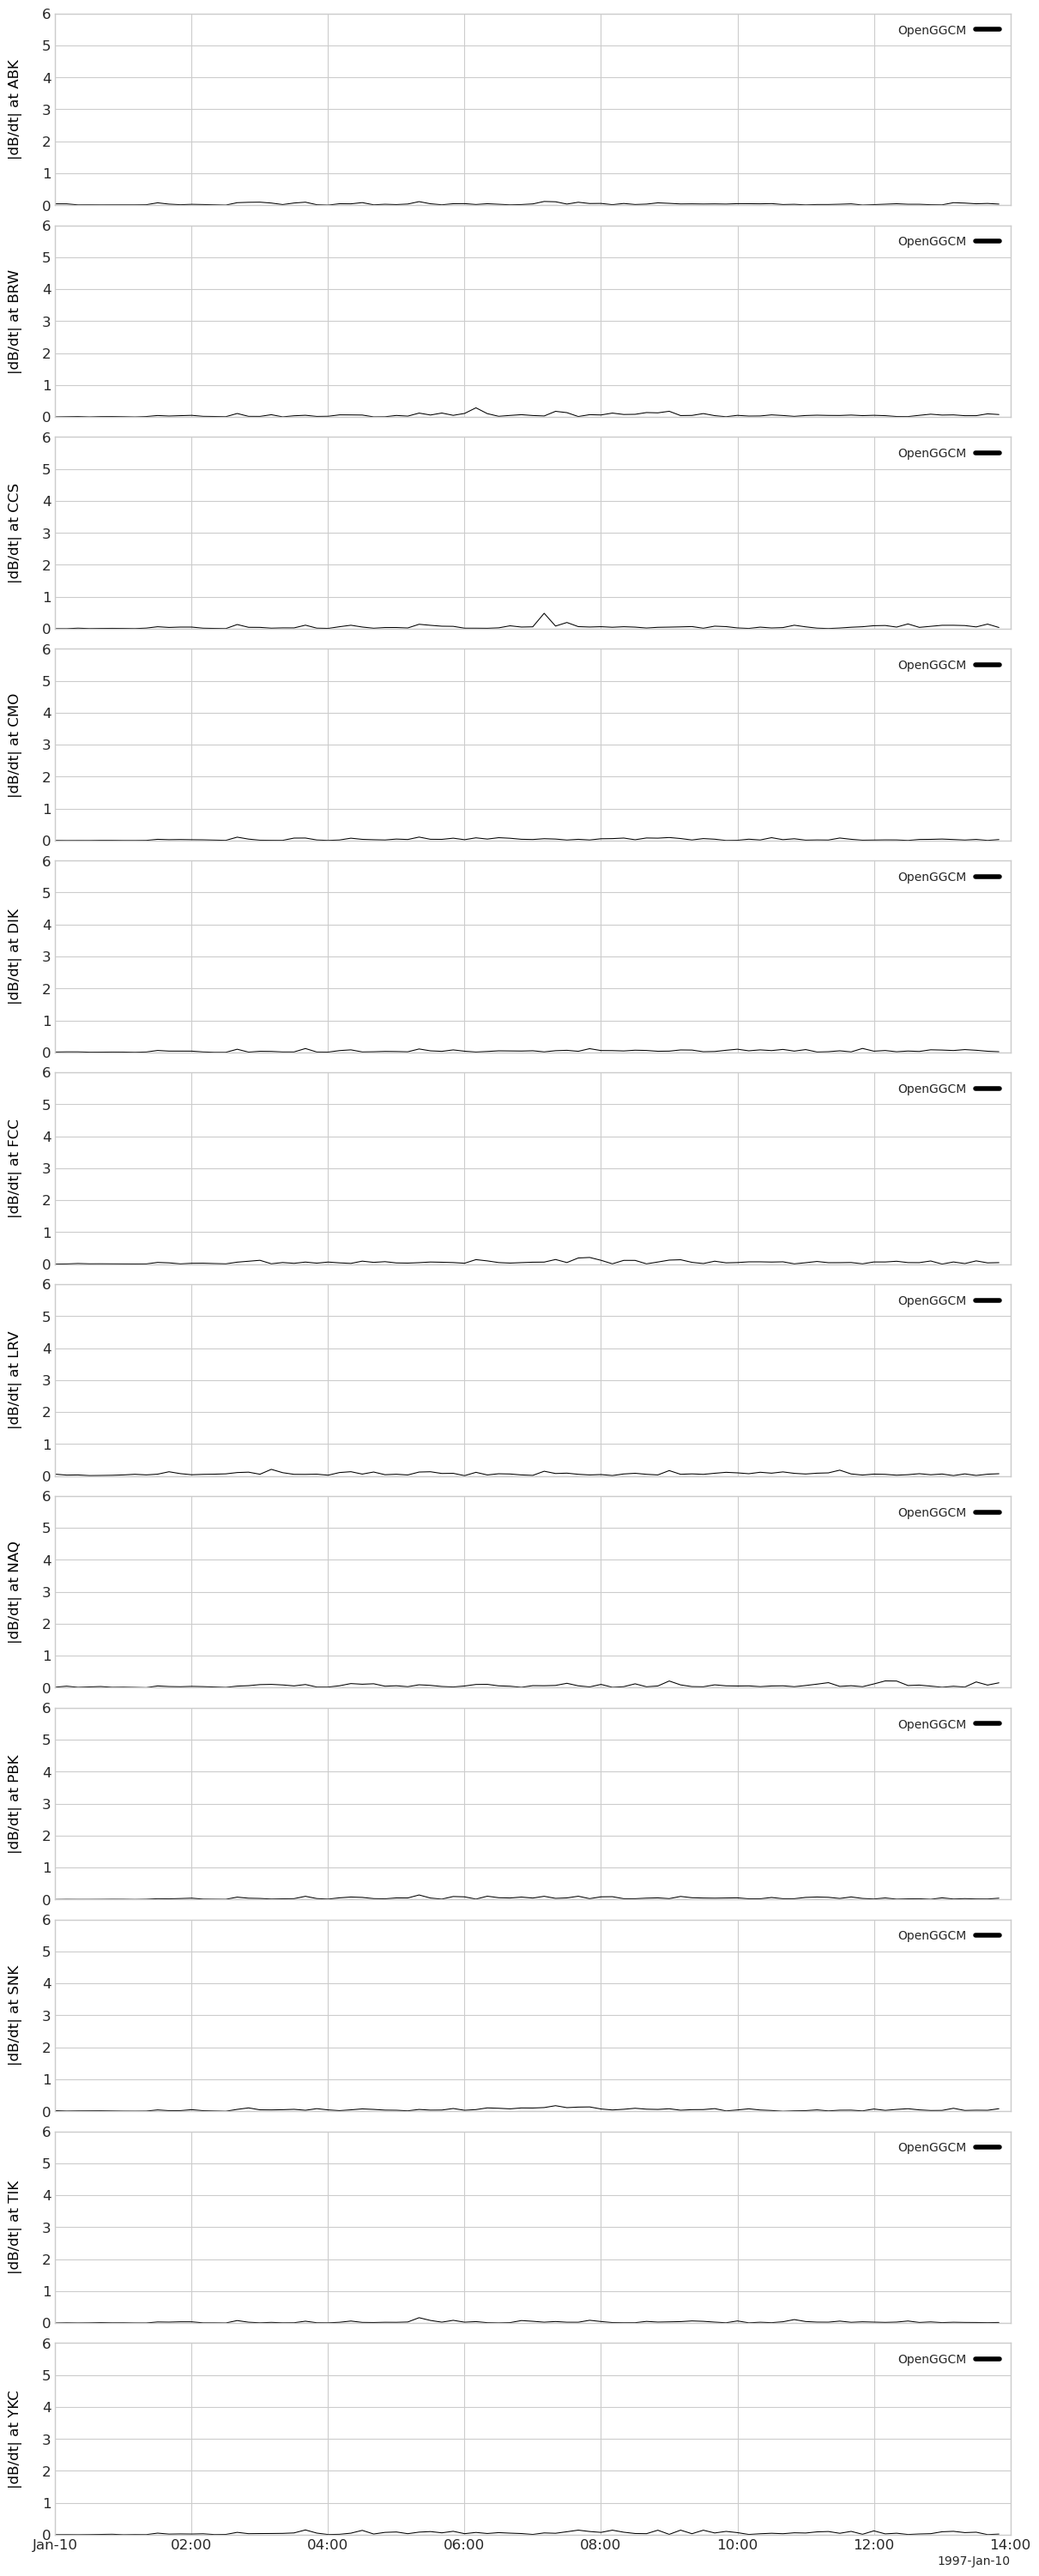

In [20]:
# Plot OpenGGCM |dB/dt| at each station.
vars_to_plot = []

for station in stations:
    vars_to_plot.append(
        f"delbh_t_sim_{station.values}",
    )
    options(
        f"delbh_t_sim_{station.values}",
        "ytitle",
        f"|dB/dt| at {station.values}",
    )

# options(vars_to_plot, "yrange", [0, delbh_t_sim_station.max().item()])
options(vars_to_plot, "yrange", [0, 6])
options(vars_to_plot, "alpha", 1.0)
options(vars_to_plot, "line_width", 0.75)
options(vars_to_plot, "legend_names", "OpenGGCM")
options(vars_to_plot, "legend_location", "upper right")

# Plot |dB/dt| at each station with a uniform `yrange`.
tplot(vars_to_plot, trange, ysize=2.5 * len(vars_to_plot))

In [21]:
# # Calculate observed |dB/dt|.
# # Map magnetometer names between OMNI and THEMIS.
# MAP_THEMIS_STATIONS = {
#     # CANOPUS -> CARISMA/THEMIS
#     "BK": "back",
#     "CL": "cont",
#     "DC": "daws",
#     "EP": "eski",
#     "FC": "fcc",
#     "FM": "mcmu",
#     "FS": "fsim",
#     "SM": "fsmi",
#     "GI": "gill",
#     "IL": "isll",
#     "PI": "pina",
#     "RB": "rabb",
#     "RI": "rank",
#     # AL
#     "ABK": "abk",
#     "BRW": "brw",
#     # "CCS": "",
#     "CMO": "cmo",
#     # "DIK": "",
#     "FCC": "fcc",
#     "LRV": "lrv",
#     "NAQ": "naq",
#     # "PBK": "",
#     "SNK": "snkq",
#     # "TIK": "",
#     "YKC": "ykc",
# }

# # Create a list of magnetometer stations using THEMIS station codes.
# station_list_obs = [
#     MAP_THEMIS_STATIONS[str(station.values)]
#     for station in stations
#     if str(station.values) in MAP_THEMIS_STATIONS
# ]

# pyspedas.projects.themis.gmag(
#     sites=station_list_obs, trange=trange, time_clip=True
# )

In [22]:
# from scipy.signal import butter, filtfilt

# # Define filter parameters (e.g., 1/600 Hz cutoff for a 300 s OpenGGCM output interval).
# fs = 1.0 / 60.0
# cutoff = 1.0 / ((iof.time[1] - iof.time[0]).item() * 1e-9 * 2)
# b, a = butter(2, (cutoff / (0.5 * fs)), btype="low", analog=False)

# station_max_obs_value_dict = {}

# # Process the observation data.
# for station in stations:
#     station_str = str(station.values)

#     if station_str not in MAP_THEMIS_STATIONS:
#         continue

#     themis_station = MAP_THEMIS_STATIONS[station_str]
#     var_obs_raw = f"thg_mag_{themis_station}"

#     # Store the output under original station names.
#     var_obs = f"delbh_t_obs_{station_str}"

#     if data_exists(var_obs_raw):
#         data_obs = get_data(var_obs_raw)
#         times = data_obs.times

#         # THEMIS GMAG [H, E, Z]
#         delbn_raw = data_obs.y[:, 0]
#         delbe_raw = data_obs.y[:, 1]

#         # Apply the filter.
#         delbn_filtered = filtfilt(b, a, delbn_raw)
#         delbe_filtered = filtfilt(b, a, delbe_raw)

#         # Calculate the derivatives.
#         dt = np.diff(times)
#         delbn_t = np.diff(delbn_filtered) / dt
#         delbe_t = np.diff(delbe_filtered) / dt

#         # Calculate the magnitude.
#         delbh_t_obs = np.sqrt(delbn_t**2 + delbe_t**2)
#         times = times[1:]

#         station_max_obs_value_dict[f"{station_str}"] = delbh_t_obs.max().item()
#         store_data(var_obs, data={"x": times, "y": delbh_t_obs})

In [23]:
# # Find the observation |dB/dt| maximum and the magnetometer station where it occurs.
# for key, value in station_max_obs_value_dict.items():
#     if value == max(station_max_obs_value_dict.values()):
#         station_max_obs_name = key
#         break

# print(
#     "The observation data maximum is",
#     max(station_max_obs_value_dict.values()),
#     "nT/s occurring at",
#     station_max_obs_name,
#     ".",
# )

In [24]:
# # Plot both observation and simulation |dB/dt| at each station.
# vars_to_plot = []

# for station in stations:
#     station_str = str(station.values)
#     var_sim = f"delbh_t_sim_{station_str}"
#     var_obs = f"delbh_t_obs_{station_str}"
#     var_combined = f"compare_{station_str}"

#     if data_exists(var_obs):
#         store_data(var_combined, data=[var_obs, var_sim])
#         options(var_combined, "legend_names", ["SuperMAG", "OpenGGCM"])
#         options(var_combined, "color", ["black", "red"])
#     else:
#         store_data(var_combined, data=var_sim)
#         options(var_combined, "legend_names", ["OpenGGCM"])
#         options(var_combined, "color", ["red"])

#     options(var_combined, "ytitle", f"|dB/dt| at {station_str}")
#     vars_to_plot.append(var_combined)

# options(vars_to_plot, "yrange", [0, delbh_t_sim_station.max().item()])
# # options(vars_to_plot, "yrange", [0, 6])
# options(vars_to_plot, "alpha", 0.75)
# options(vars_to_plot, "line_width", 0.75)

# # Plot |dB/dt| at each station.
# tplot(vars_to_plot, trange, ysize=2.5 * len(vars_to_plot))

In [25]:
# Set geomagnetic data plotting options.

# IMF Bz
options("BZ_GSE", "ytitle", "IMF Bz")
options("BZ_GSE", "yrange", [-20, 20])

# Solar Wind Speed
options("flow_speed", "ytitle", "Speed")

# Solar Wind Density
options("proton_density", "ytitle", "Density")
options("proton_density", "ylog", True)
options("proton_density", "yrange", [1, 100])

# Flow Pressure (Dynamic Pressure)
options("Pressure", "ytitle", "Dyn. Pressure")

# AE Index
options("AE_INDEX", "ytitle", "AE Index")

# AL Index
options("al", "ytitle", "AL Index")
options("al", "yrange", [-2000, 0])
options("al", "color", ["black", "red"])
options("al", "legend_names", ["OMNI", "OpenGGCM"])
options("al", "legend_location", "lower right")

# CPCP
options("cpcp_north", "yrange", [0, 700])
options("cpcp_north", "legend_names", "OpenGGCM")
options("cpcp_north", "legend_location", "upper right")

# Joule heating
options("jh_north", "ylog", True)
options("jh_north", "yrange", [1, 10000])
options("jh_north", "legend_names", "OpenGGCM")
options("jh_north", "legend_location", "upper right")

# |dB/dt| at the station with the maximum value
options(
    f"delbh_t_sim_{station_max_sim_name}",
    "yrange",
    # [0, delbh_t_sim_station.max().values.item()],
    [0, 6],
)
options(f"delbh_t_sim_{station_max_sim_name}", "legend_names", "OpenGGCM")
options(
    f"delbh_t_sim_{station_max_sim_name}", "legend_location", "upper right"
)

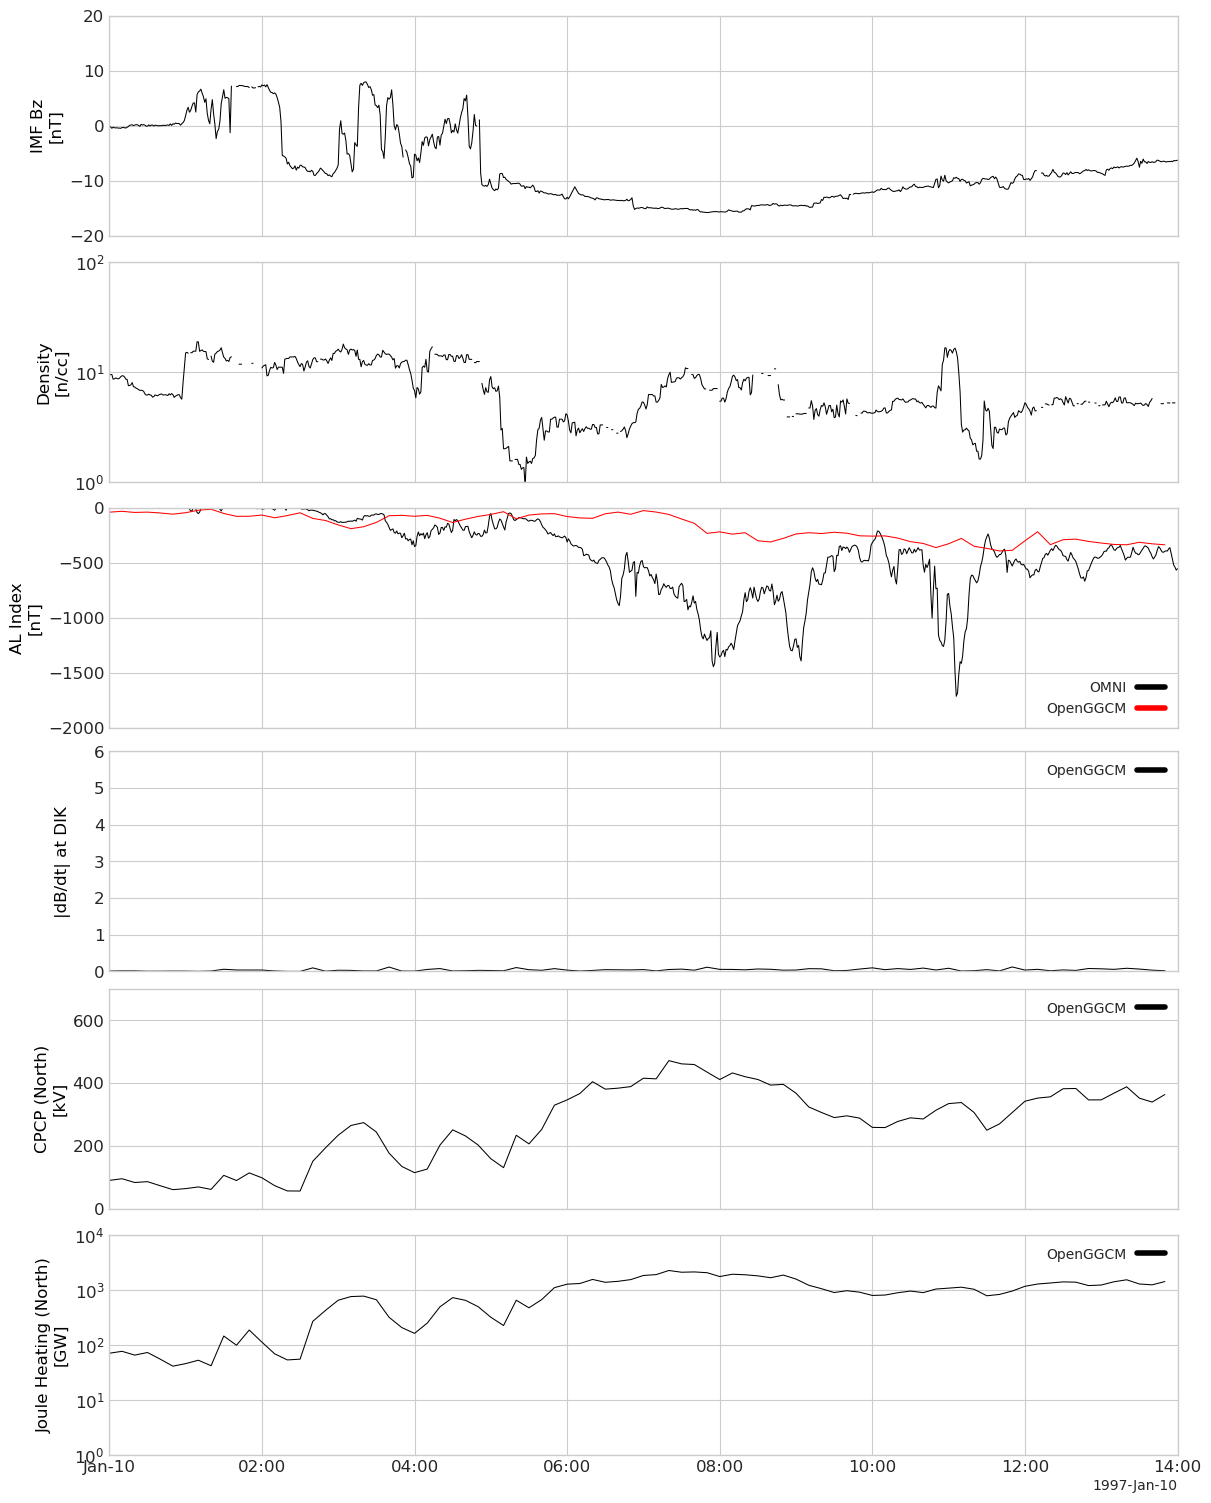

In [26]:
vars_to_plot = [
    "BZ_GSE",
    "proton_density",
    # "flow_speed",
    # "SYM_H",
    "al",
    f"delbh_t_sim_{station_max_sim_name}",
    # f"compare_{station_max_sim_name}",
    # f"compare_{station_max_obs_name}",
    "cpcp_north",
    "jh_north",
]

options(vars_to_plot, "alpha", 1.0)
options(vars_to_plot, "line_width", 0.75)

# Plot the geomagnetic data.
tplot(vars_to_plot, trange, ysize=2.5 * len(vars_to_plot))

In [27]:
# mag_files = sorted(DATA_DIR.glob(f"{RUN_NAME}.py_0.*"))
# py_0 = xr.open_mfdataset(mag_files)

In [28]:
# Determine the maximum time step and interval.
time_max = iof.time.shape[0]
interval = int(time_max / 6)

In [29]:
# # Density
# py_0.rr.sel(x=slice(-50.0, 100.0), z=slice(-50.0, 50.0)).isel(time=slice(0, time_max, int(interval / 2))).T.plot(
#     col="time", col_wrap=4, aspect=1.5, size=4, norm=colors.LogNorm()
# );

In [30]:
# # Pressure
# py_0.pp.sel(x=slice(-50.0, 100.0), z=slice(-50.0, 50.0)).isel(time=slice(0, time_max, int(interval / 2))).T.plot(
#     col="time", col_wrap=4, aspect=1.5, size=4, norm=colors.LogNorm()
# );

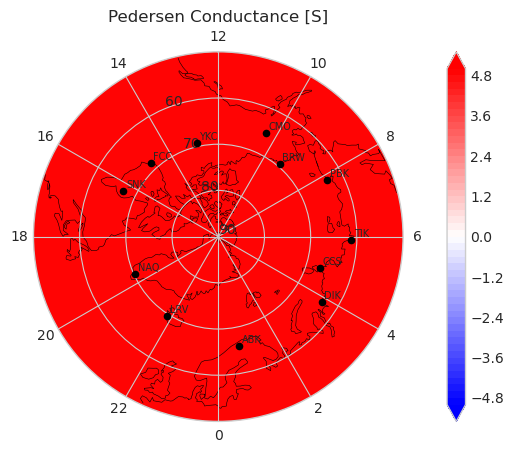

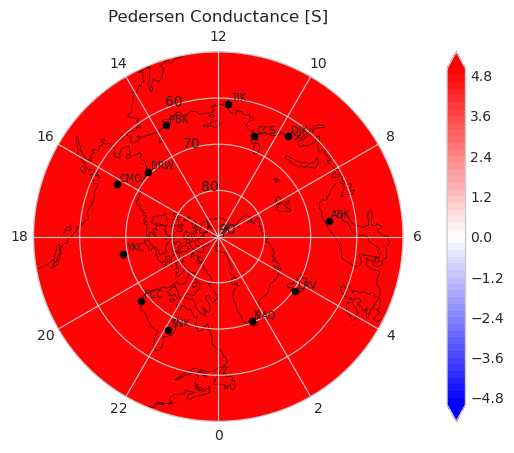

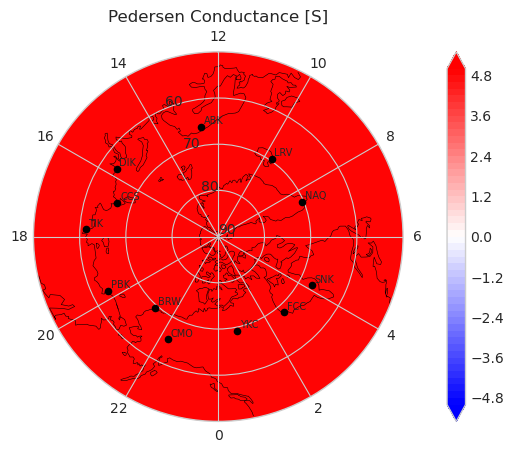

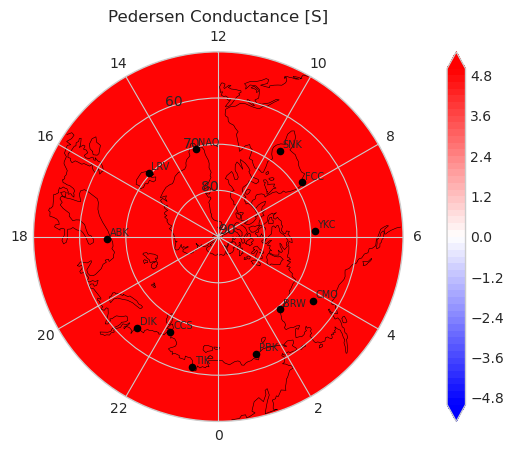

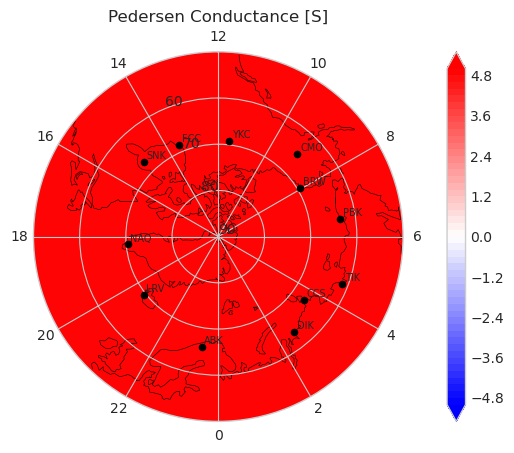

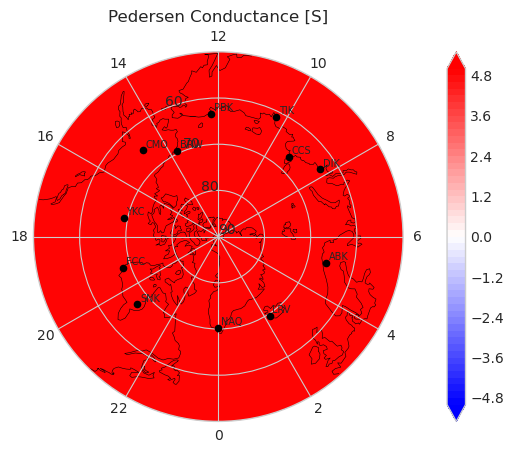

In [31]:
# Pedersen and Hall conductances
for i in range(0, time_max, interval):
    iof.isel(time=i).sigp.ggcm.plot(
        coastlines=True,
        stations=True,
    )

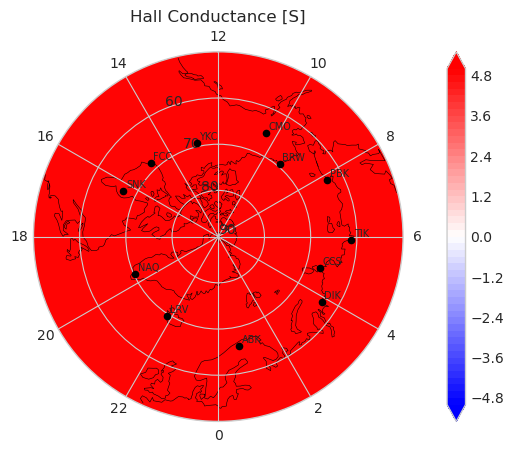

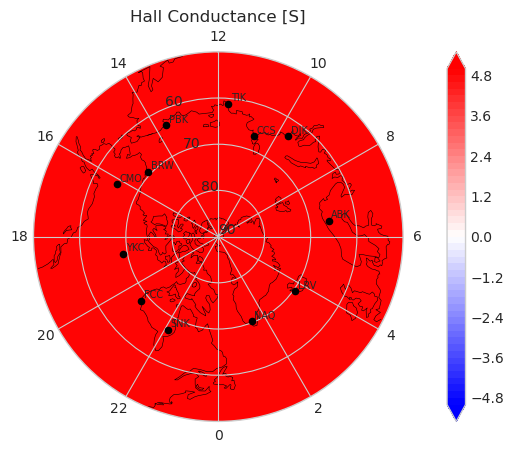

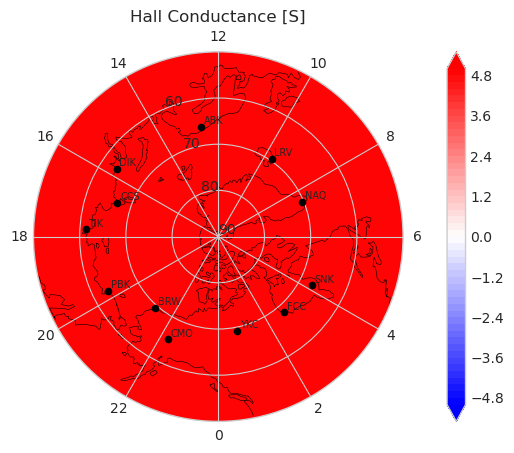

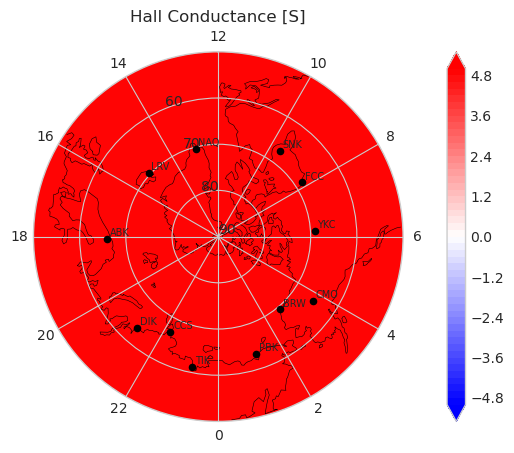

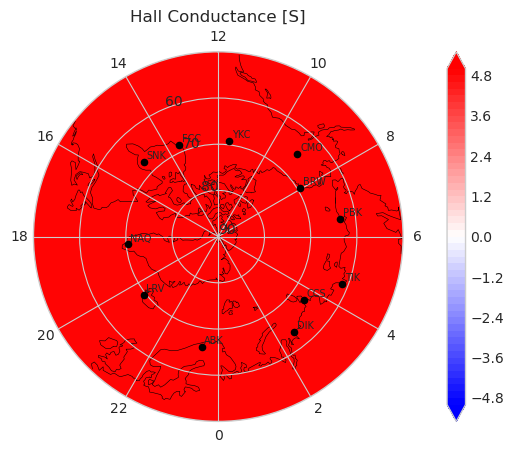

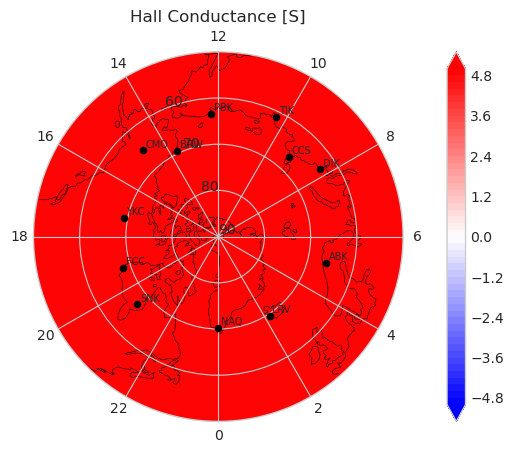

In [32]:
for i in range(0, time_max, interval):
    iof.isel(time=i).sigh.ggcm.plot(
        coastlines=True,
        stations=True,
    )

In [33]:
# # Diffuse and discrete electron precipitation energy flux
# for i in range(0, time_max, interval):
#     iof.isel(time=i).prec_e_fe_1.ggcm.plot(
#         coastlines=True,
#         stations=True,
#     )

In [34]:
# for i in range(0, time_max, interval):
#     iof.isel(time=i).prec_e_fe_2.ggcm.plot(
#         coastlines=True,
#         stations=True,
#     )

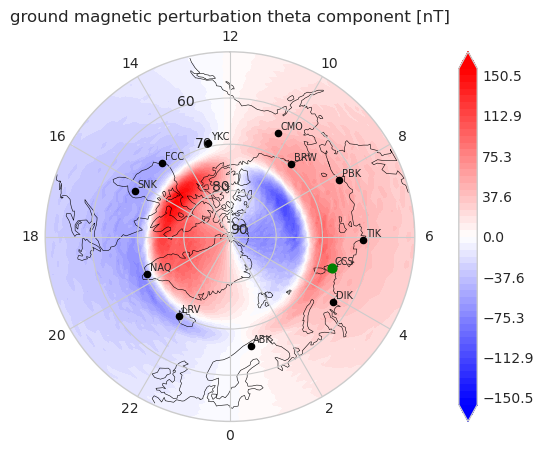

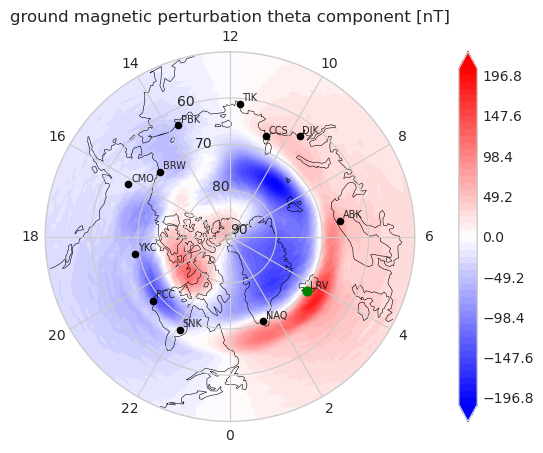

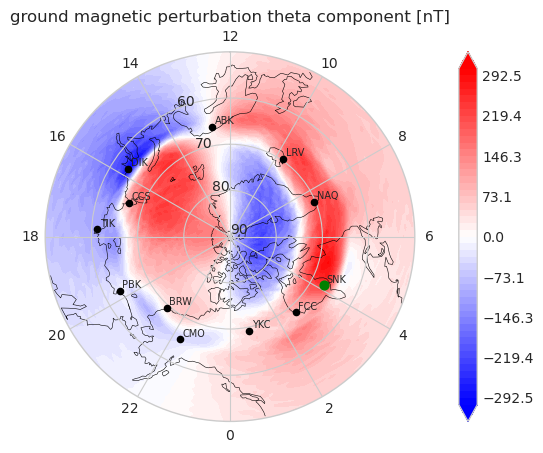

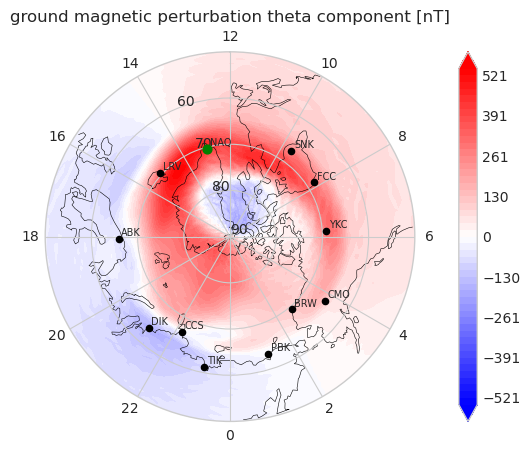

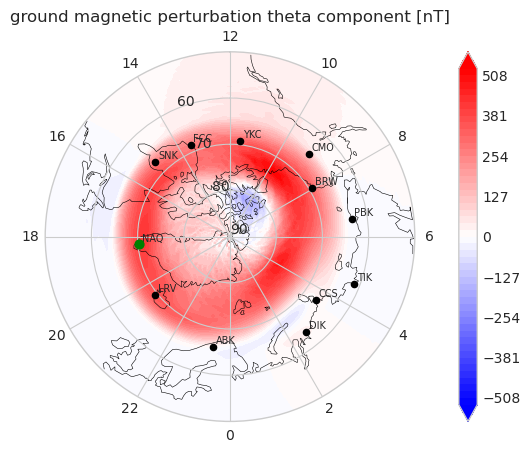

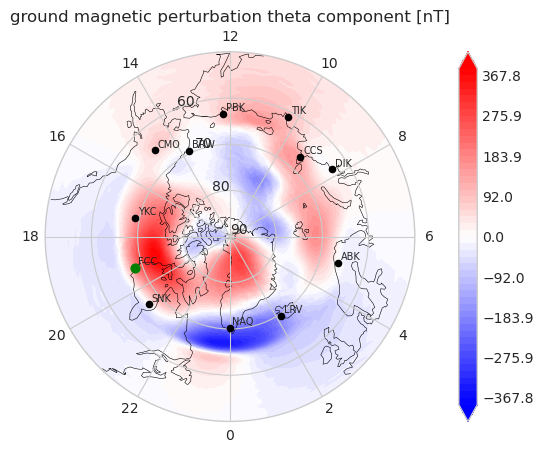

In [35]:
iof["delbt"] *= 1e9

for i in range(0, time_max, interval):
    current_station = str(ggcm_al["ggcm.al_station"].isel(time=i).item())
    iof["delbt"].isel(time=i).ggcm.plot(
        coastlines=True, stations=True, highlight_station=current_station
    )

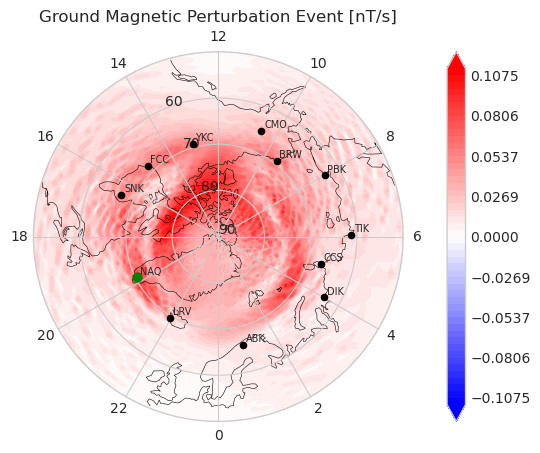

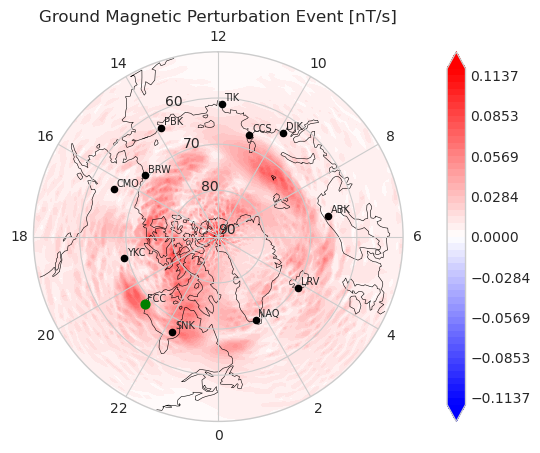

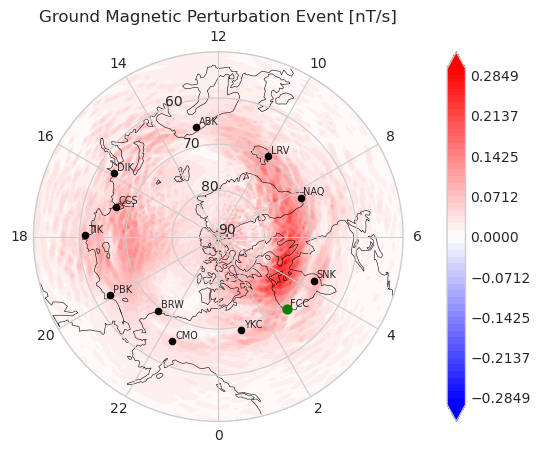

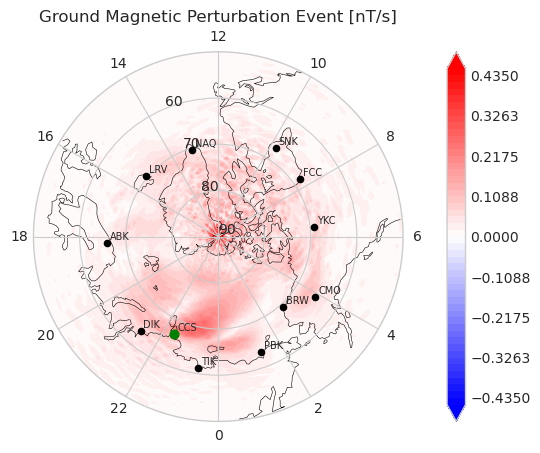

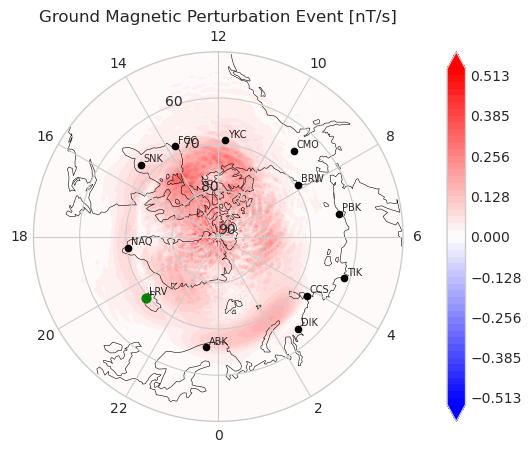

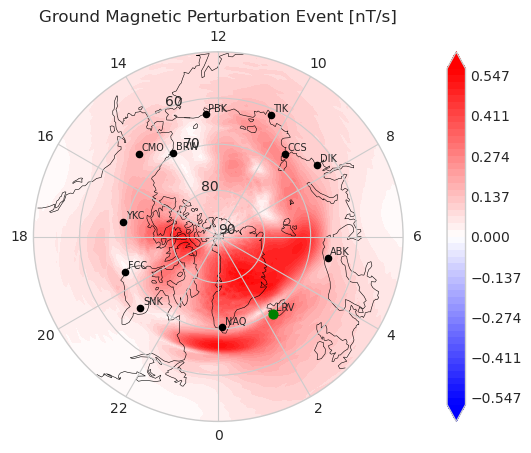

In [36]:
for i in range(1, time_max, interval):
    station_max_sim_name_one_time = (
        delbh_t_sim_station.where(
            delbh_t_sim_station == delbh_t_sim_station.isel(time=i).max(),
            drop=True,
        )
        .coords["station"]
        .item()
    )
    current_station = station_max_sim_name_one_time
    delbh_t_sim.isel(time=i).ggcm.plot(
        coastlines=True, stations=True, highlight_station=current_station
    )